# 10b · Bootstrap Yöntemi
**Probability Lab** · Simulation Module

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Buraya kadar öğrendiğin güven aralığı yöntemleri (06b'deki CLT-tabanlı) hep belirli
> varsayımlara dayanıyordu (Normal dağılım, formülü bilinen bir standart hata). Ama gerçek
> hayatta "medyan için güven aralığı" veya "korelasyonun güven aralığı" gibi sorular
> sorduğunda, CLT'nin basit formülleri artık işe yaramıyor. **Bootstrap**, bu sorunu tamamen
> farklı bir şekilde çözüyor: hiçbir dağılım varsayımı yapmadan, **elindeki tek örneklemi
> tekrar tekrar örnekleyerek** (yerine koyarak) belirsizliği doğrudan simüle ediyor. Bu,
> `probability-lab` serisinin son ve en "pratik" konusu — artık her yerde kullanabileceğin
> evrensel bir araç.

**Önkoşul:** Merkezi Limit Teoremi (06b), Monte Carlo Simülasyonu (10a)  
**Veri:**  
- `insurance.csv` — Sağlık sigortası (10a'dan devam, aynı `data/` klasöründe)  
- `seaborn.load_dataset("tips")` — Restoran bahşiş verisi (yerleşik, indirme gerekmez)  
**Araçlar:** Python (numpy, scipy), R (base R), SQL (DuckDB)

---
## 1 · Sezgi: Elimde Tek Bir Örneklem Var, Ama Belirsizliği Bilmek İstiyorum

Diyelim ki 50 kişilik bir örneklemden ortalama sigorta harcamasını hesapladın: $\bar{x}=13.500$.
Bu tek sayı, gerçek popülasyon ortalamasının ($\mu$) **kesin değeri değil**, sadece bir
tahmin. Soru şu: *bu tahmin ne kadar güvenilir? Başka bir 50 kişilik örneklem alsaydım,
ne kadar farklı bir sayı çıkardı?*

06b'de bu soruyu CLT ile cevapladık: $SE=\sigma/\sqrt{n}$ formülüyle. Ama bu formül **sadece
ortalama için** kolay bir kapalı-form'a sahip. Ya *medyanın* belirsizliğini merak ediyorsan?
Ya iki değişken arası *korelasyonun* belirsizliğini? Bu istatistikler için ya çok karmaşık
formüller gerekiyor ya da hiç yok. Bootstrap, tam bu noktada devreye giriyor.

---
## 2 · Bootstrap'ın Temel Fikri: Örneklemi "Sahte Popülasyon" Gibi Kullanmak

Gerçek popülasyona bir daha erişemezsin (sadece elindeki 50 kişilik örneklemin var). Ama
istatistikçi Bradley Efron'un 1979'daki dâhiyane fikri şuydu: **elindeki örneklemin kendisini,
geçici olarak "popülasyon" gibi davran.** Bu sahte popülasyondan **yerine koyarak** (with
replacement) tekrar tekrar $n$ büyüklüğünde örnekler çek — her birine **bootstrap örneklemi**
denir.

**Neden "yerine koyarak"?** Eğer yerine koymadan çekseydin, her seferinde aynı 50 kişiyi
farklı sırada alırdın — hiçbir yeni bilgi üretmezdi. Yerine koyarak çekince, bazı kişiler
bir bootstrap örnekleminde 2-3 kez görünebilir, bazıları hiç görünmeyebilir — bu **rastgele
varyasyon**, gerçek dünyada "başka bir örneklem alsaydım ne olurdu" sorusunu simüle ediyor.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Kucuk, somut bir orneklem: 8 kisilik hayali yas verisi
orijinal_ornek = np.array([25, 31, 22, 45, 38, 29, 41, 33])
print("Orijinal örneklem:", orijinal_ornek)
print(f"Orijinal örneklem ortalaması: {orijinal_ornek.mean():.2f}\n")

rng = np.random.default_rng(42)
print("=== 5 Farklı Bootstrap Örneklemi (yerine koyarak çekiliyor) ===")
for i in range(5):
    bootstrap_ornek = rng.choice(orijinal_ornek, size=len(orijinal_ornek), replace=True)
    print(f"Bootstrap #{i+1}: {bootstrap_ornek}  -> ortalama={bootstrap_ornek.mean():.2f}")

print("\nGÖZLEM: Her bootstrap örnekleminde bazı değerler tekrar ediyor, bazıları hiç yok.")
print(f"Ortalamalar da orijinal örneklemin ortalaması ({orijinal_ornek.mean():.2f}) etrafında AMA farklı değerler alıyor -")
print("işte bu farklılık, 'gerçek belirsizliği' simüle ediyor.")

Orijinal örneklem: [25 31 22 45 38 29 41 33]
Orijinal örneklem ortalaması: 33.00

=== 5 Farklı Bootstrap Örneklemi (yerine koyarak çekiliyor) ===
Bootstrap #1: [25 41 29 45 45 41 25 29]  -> ortalama=35.00
Bootstrap #2: [31 25 38 33 29 41 29 41]  -> ortalama=33.38
Bootstrap #3: [38 31 41 45 38 22 31 33]  -> ortalama=34.88
Bootstrap #4: [41 29 45 41 38 45 45 31]  -> ortalama=39.38
Bootstrap #5: [25 38 33 25 41 41 22 29]  -> ortalama=31.75

GÖZLEM: Her bootstrap örnekleminde bazı değerler tekrar ediyor, bazıları hiç yok.
Ortalamalar da orijinal örneklemin ortalaması (33.00) etrafında AMA farklı değerler alıyor -
işte bu farklılık, 'gerçek belirsizliği' simüle ediyor.


---
## 3 · Bootstrap Algoritması: Adım Adım

1. Elindeki örneklem $x_1,\dots,x_n$'den, **yerine koyarak** $n$ büyüklüğünde rastgele bir
   örneklem çek (bir "bootstrap örneklemi")
2. Bu bootstrap örnekleminde ilgilendiğin istatistiği hesapla (ortalama, medyan, korelasyon —
   ne olursa olsun)
3. 1-2 adımlarını **$B$ kere tekrarla** (genelde $B=1000$ veya $B=10000$)
4. Elinde artık $B$ tane istatistik değeri var — bunların dağılımı, **o istatistiğin
   örnekleme dağılımının bir tahminidir**
5. Güven aralığı için, bu $B$ değerin **yüzdelik dilimlerini** al (örn. %95 CI için 2.5. ve
   97.5. yüzdelikler) — buna **percentile method** denir (en basit ve en yaygın kullanılan yöntem)

---
## 4 · Bootstrap Güven Aralığı Yöntemleri (Kısa Bir Bakış)

En yaygın üç yöntem var, biz bu notebook'ta ağırlıklı olarak birinciyi kullanacağız:

- **Percentile Method:** $B$ bootstrap istatistiğinin ham yüzdelik dilimlerini kullan (basit, sezgisel, çoğu durumda yeterli)
- **Normal-tabanlı Method:** Bootstrap dağılımının Normal olduğunu varsayıp $\bar{x}\pm z\times SE_{bootstrap}$ formülünü kullan (CLT'ye geri dönüş, ama $SE$'yi Bootstrap'tan alıyorsun)
- **BCa (Bias-Corrected and accelerated):** Percentile yöntemini, dağılımın çarpıklığına göre düzeltir (daha isabetli ama daha karmaşık — `scipy.stats.bootstrap`'ın varsayılan yöntemi)

Bu notebook'ta çoğunlukla **percentile method** kullanacağız çünkü anlaşılması en kolay ve
pratikte çoğu zaman yeterince iyi çalışıyor.

---
## 5 · Ne Zaman Bootstrap Başarısız Olur?

Bootstrap sihirli bir değnek değil — birkaç önemli sınırlaması var:

- **Çok küçük örneklem ($n<10$ gibi):** Orijinal örneklem popülasyonu iyi temsil etmiyorsa,
  bootstrap örneklemler de aynı "kör noktaları" miras alır — gerçek belirsizliği olduğundan
  az gösterebilir.
- **Aşırı uç değerler (extreme statistics):** Maksimum/minimum gibi istatistikler için
  bootstrap kötü performans gösterir, çünkü yerine koyarak örneklemede en uç değeri "yakalama
  şansı" sınırlı.
- **Bağımlı veri (zaman serisi gibi):** Standart bootstrap, gözlemlerin **bağımsız** olduğunu
  varsayıyor. Zaman serisi gibi ardışık bağımlılığı olan veride, özel "blok bootstrap" gibi
  varyantlar gerekiyor (bu notebook'un kapsamı dışında).

Bölüm 9'da (Python 5) bu sınırlamalardan birini somut olarak göstereceğiz.

---
## 6 · Özet Tablo: Bootstrap vs Analitik (CLT-tabanlı) Yöntemler

| | Analitik (CLT-tabanlı) | Bootstrap |
|---|---|---|
| Dağılım varsayımı | Genelde Normal yaklaşımı gerekir | Yok — veri kendi konuşuyor |
| Formül gerekli mi? | Evet (her istatistik için ayrı formül) | Hayır — aynı algoritma her istatistikte çalışır |
| Ortalama için | Hızlı, kesin | Aynı sonucu verir, ama hesaplama maliyeti var |
| Medyan/korelasyon için | Karmaşık veya formül yok | Doğrudan çalışır |
| Hesaplama maliyeti | Düşük | Yüksek (binlerce tekrar örnekleme) |
| Küçük örneklemde | CLT varsayımı bozulabilir | Orijinal örneklemin kalitesine bağımlı |

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Bootstrap vs Analitik CI — Ortalama İçin** — İkisinin aynı sonucu verdiğini kanıtlama
2. **Bootstrap CI — Medyan İçin** — Analitik formülün olmadığı yerde bootstrap'ın gücü
3. **Bootstrap CI — Korelasyon İçin** — `scipy.stats.bootstrap` ile hazır fonksiyon kullanımı
4. **Bootstrap — Regresyon Katsayısı İçin** — Modelin kendisini bootstrap'lama
5. **Bootstrap'ın Sınırlaması** — Çok küçük örneklemde neler ters gidebilir

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 💵 Python 1 — Bootstrap vs Analitik CI: Ortalama İçin Aynı Sonuç

**Ne yapıyoruz?**  
`tips` veri setinde bahşiş miktarının ortalaması için hem 06b'deki CLT-tabanlı analitik
güven aralığını hem de bootstrap güven aralığını hesaplayıp, ikisinin ne kadar örtüştüğünü göreceğiz.

Veri: 244 sipariş, ortalama bahşiş: 2.998

Analitik (CLT) %95 CI: [2.8247, 3.1719]
Bootstrap (percentile) %95 CI: [2.8262, 3.1739]


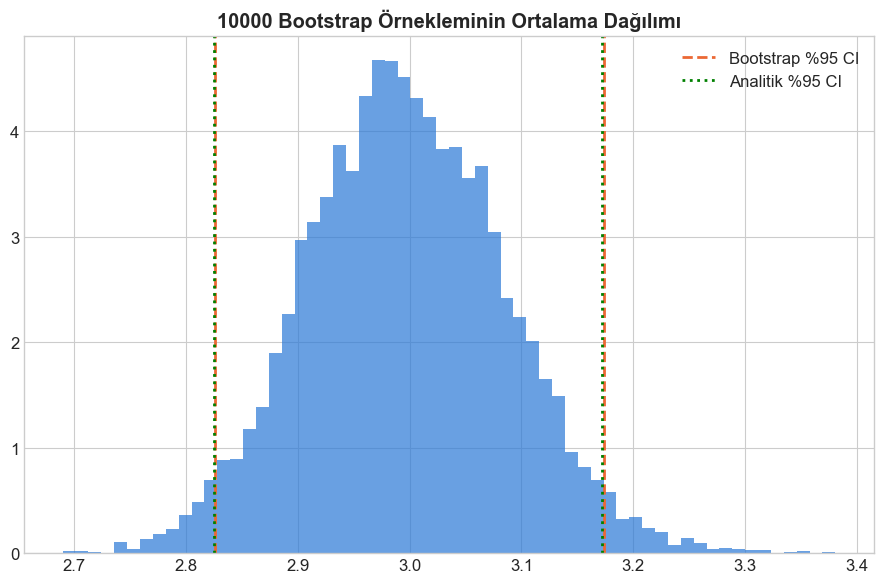


YORUM: İki yöntemin CI'ları neredeyse birebir örtüşüyor - bu beklenen bir sonuç,
çünkü CLT zaten ortalamanın Normal'e yakınsadığını garanti ediyordu. Bootstrap'ın
gerçek gücü, aşağıdaki gibi CLT'nin kolay formül vermediği durumlarda ortaya çıkıyor.


In [3]:
tips = sns.load_dataset('tips')
bahsis = tips['tip'].values
n = len(bahsis)
print(f"Veri: {n} sipariş, ortalama bahşiş: {bahsis.mean():.3f}")

# ===== ANALITIK CI (CLT-tabanli, 06b'deki formul) =====
x_bar = bahsis.mean()
se_analitik = bahsis.std(ddof=1) / np.sqrt(n)
z_995 = stats.norm.ppf(0.975)
ci_analitik = (x_bar - z_995*se_analitik, x_bar + z_995*se_analitik)
print(f"\nAnalitik (CLT) %95 CI: [{ci_analitik[0]:.4f}, {ci_analitik[1]:.4f}]")

# ===== BOOTSTRAP CI =====
rng = np.random.default_rng(42)
B = 10000
bootstrap_ortalamalar = np.array([
    rng.choice(bahsis, size=n, replace=True).mean() for _ in range(B)
])
ci_bootstrap = np.percentile(bootstrap_ortalamalar, [2.5, 97.5])
print(f"Bootstrap (percentile) %95 CI: [{ci_bootstrap[0]:.4f}, {ci_bootstrap[1]:.4f}]")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(bootstrap_ortalamalar, bins=60, color='#2a78d6', alpha=0.7, density=True)
ax.axvline(ci_bootstrap[0], color='#eb6834', linestyle='--', linewidth=2, label='Bootstrap %95 CI')
ax.axvline(ci_bootstrap[1], color='#eb6834', linestyle='--', linewidth=2)
ax.axvline(ci_analitik[0], color='green', linestyle=':', linewidth=2, label='Analitik %95 CI')
ax.axvline(ci_analitik[1], color='green', linestyle=':', linewidth=2)
ax.set_title(f'{B} Bootstrap Örnekleminin Ortalama Dağılımı', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: İki yöntemin CI'ları neredeyse birebir örtüşüyor - bu beklenen bir sonuç,")
print("çünkü CLT zaten ortalamanın Normal'e yakınsadığını garanti ediyordu. Bootstrap'ın")
print("gerçek gücü, aşağıdaki gibi CLT'nin kolay formül vermediği durumlarda ortaya çıkıyor.")

---
### 📊 Python 2 — Bootstrap CI: Medyan İçin (CLT'nin Kolay Cevabı Olmayan Bir Durum)

**Ne yapıyoruz?**  
Medyanın örnekleme dağılımı için basit bir kapalı-form formül yok (ortalamanınki gibi
$\sigma/\sqrt{n}$ değil). Bootstrap, hiçbir formül bilmeden bu sorunu direkt çözüyor.

Örneklem medyanı: 2.900
Bootstrap %95 CI (medyan): [2.5000, 3.0000]


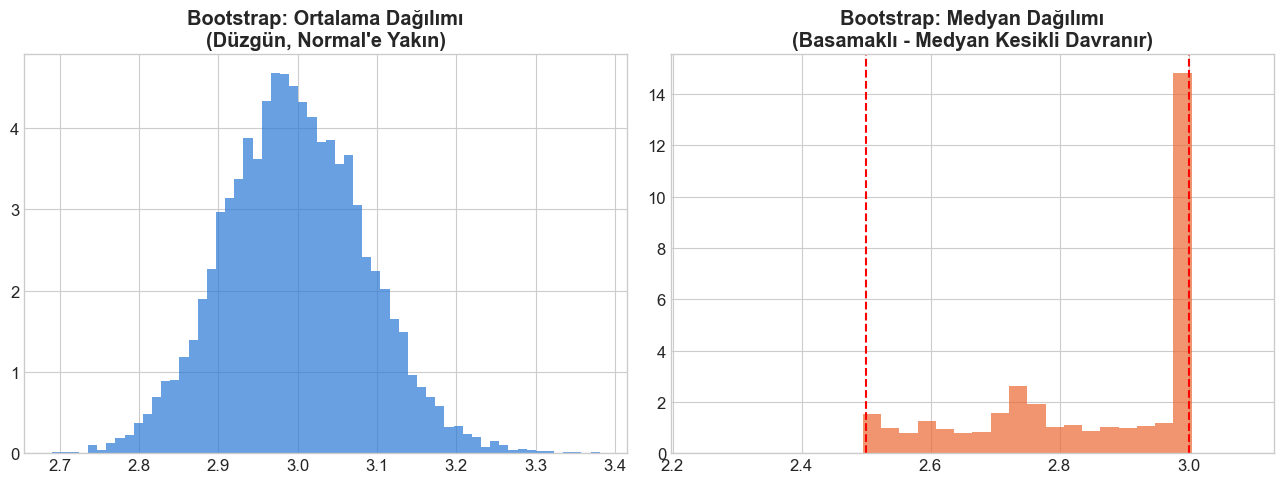


YORUM: Medyanın bootstrap dağılımı 'basamaklı' görünüyor çünkü medyan sadece
veri setindeki GERÇEK değerlerden birini alabiliyor (ortalama gibi sürekli değişmiyor).
Buna rağmen bootstrap, hiçbir özel formül gerektirmeden CI'ı doğru şekilde üretti.


In [4]:
medyan_gercek = np.median(bahsis)
print(f"Örneklem medyanı: {medyan_gercek:.3f}")

bootstrap_medyanlar = np.array([
    np.median(rng.choice(bahsis, size=n, replace=True)) for _ in range(B)
])
ci_medyan = np.percentile(bootstrap_medyanlar, [2.5, 97.5])
print(f"Bootstrap %95 CI (medyan): [{ci_medyan[0]:.4f}, {ci_medyan[1]:.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(bootstrap_ortalamalar, bins=60, color='#2a78d6', alpha=0.7, density=True)
axes[0].set_title('Bootstrap: Ortalama Dağılımı\n(Düzgün, Normal\'e Yakın)', fontweight='bold')

axes[1].hist(bootstrap_medyanlar, bins=30, color='#eb6834', alpha=0.7, density=True)
axes[1].axvline(ci_medyan[0], color='red', linestyle='--')
axes[1].axvline(ci_medyan[1], color='red', linestyle='--')
axes[1].set_title('Bootstrap: Medyan Dağılımı\n(Basamaklı - Medyan Kesikli Davranır)', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nYORUM: Medyanın bootstrap dağılımı 'basamaklı' görünüyor çünkü medyan sadece")
print("veri setindeki GERÇEK değerlerden birini alabiliyor (ortalama gibi sürekli değişmiyor).")
print("Buna rağmen bootstrap, hiçbir özel formül gerektirmeden CI'ı doğru şekilde üretti.")

---
### 🔗 Python 3 — Bootstrap CI: Korelasyon İçin (`scipy.stats.bootstrap` ile)

**Ne yapıyoruz?**  
`insurance.csv`'de yaş (`age`) ile harcama (`charges`) arasındaki Pearson korelasyonunun
güven aralığını, bu sefer elle döngü yazmadan `scipy.stats.bootstrap`'ın hazır fonksiyonuyla
hesaplayacağız — gerçek projelerde kullanacağın araç bu.

Örneklem korelasyonu (age vs charges): r = 0.2990
Bootstrap %95 CI: [0.2495, 0.3475]


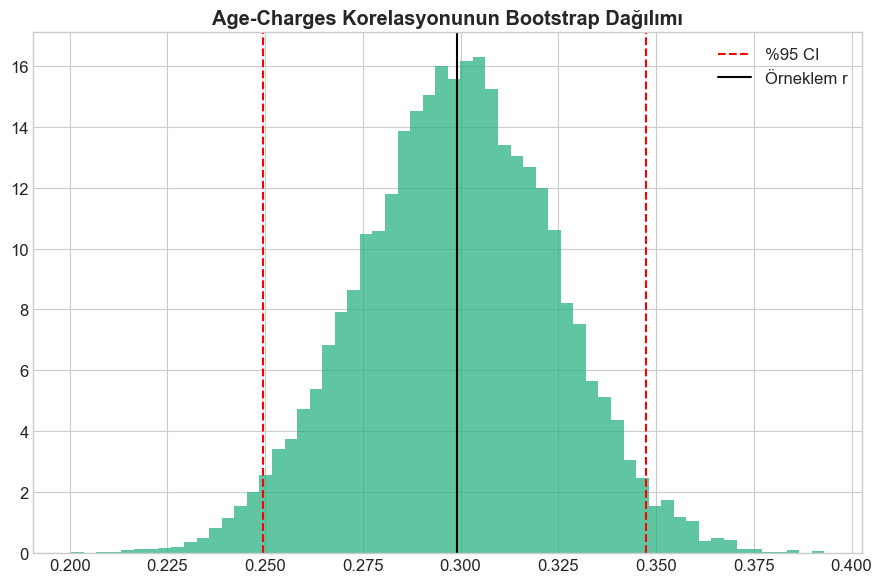


ÖNEMLİ NOT: paired=True kullandık çünkü x (age) ve y (charges) ÇİFTLER halinde
anlamlı - bir kişinin yaşını başka bir kişinin harcamasıyla eşleştirirsek korelasyon
kavramı anlamını yitirir. Bootstrap'ta ÇİFTLERİ birlikte yeniden örneklemek şart.


In [5]:
insurance = pd.read_csv('data/insurance.csv')
age = insurance['age'].values
charges = insurance['charges'].values

r_gercek, p_value = stats.pearsonr(age, charges)
print(f"Örneklem korelasyonu (age vs charges): r = {r_gercek:.4f}")

def korelasyon_istatistigi(x, y):
    return stats.pearsonr(x, y)[0]

sonuc = stats.bootstrap(
    (age, charges), korelasyon_istatistigi,
    n_resamples=10000, method='percentile', random_state=42,
    paired=True  # x ve y CIFTLER halinde birlikte orneklenmeli (birini digerinden bagimsiz karistirma!)
)

print(f"Bootstrap %95 CI: [{sonuc.confidence_interval.low:.4f}, {sonuc.confidence_interval.high:.4f}]")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(sonuc.bootstrap_distribution, bins=60, color='#1baf7a', alpha=0.7, density=True)
ax.axvline(sonuc.confidence_interval.low, color='red', linestyle='--', label='%95 CI')
ax.axvline(sonuc.confidence_interval.high, color='red', linestyle='--')
ax.axvline(r_gercek, color='black', linestyle='-', label='Örneklem r')
ax.set_title('Age-Charges Korelasyonunun Bootstrap Dağılımı', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nÖNEMLİ NOT: paired=True kullandık çünkü x (age) ve y (charges) ÇİFTLER halinde")
print("anlamlı - bir kişinin yaşını başka bir kişinin harcamasıyla eşleştirirsek korelasyon")
print("kavramı anlamını yitirir. Bootstrap'ta ÇİFTLERİ birlikte yeniden örneklemek şart.")

---
### 📈 Python 4 — Bootstrap: Regresyon Katsayısının Güven Aralığı

**Ne yapıyoruz?**  
08'deki MLE=OLS bağlantısını hatırla — regresyon katsayıları da birer tahmin, ve onların da
belirsizliği var. Bu sefer **tüm regresyon modelini** bootstrap'layarak, `age` katsayısının
güven aralığını (istatistik paketlerinin `summary()` çıktısında gördüğün p-value'ların
arkasındaki mantığı) elde edeceğiz.

Orijinal örneklemden katsayı (age): 241.931
Bootstrap %95 CI (age katsayısı): [197.197, 284.241]


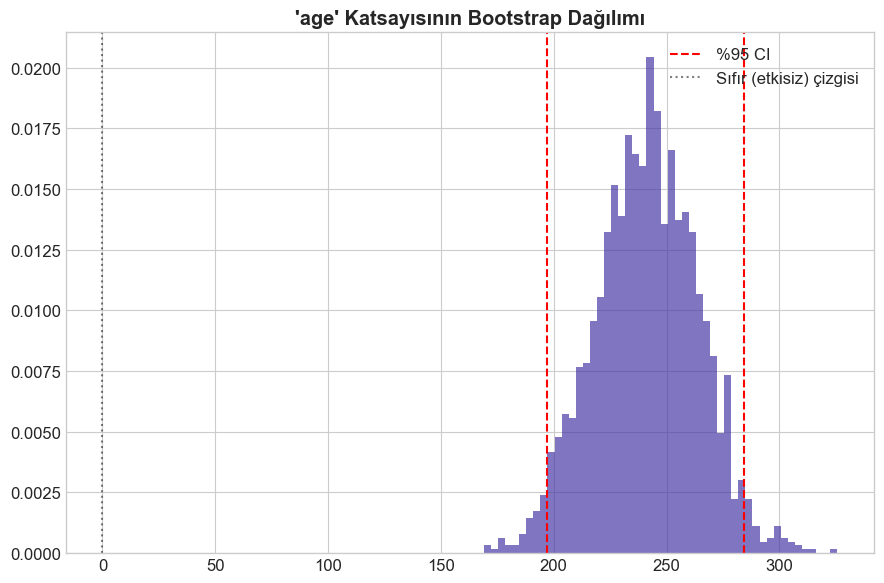


YORUM: CI sıfırı içermiyorsa, 'age'in charges üzerinde istatistiksel olarak anlamlı
bir etkisi olduğunu düşünebilirsin - bu, klasik regresyon çıktılarındaki p-value'nun
bootstrap ile 'formül bilmeden' elde edilmiş hali.


In [6]:
from sklearn.linear_model import LinearRegression

X_orig = insurance[['age', 'bmi']].values
y_orig = insurance['charges'].values
n_ins = len(y_orig)

ols_orig = LinearRegression().fit(X_orig, y_orig)
print(f"Orijinal örneklemden katsayı (age): {ols_orig.coef_[0]:.3f}")

bootstrap_katsayilar = []
for _ in range(2000):
    idx = rng.integers(0, n_ins, n_ins)  # satir indekslerini yerine koyarak yeniden ornekle
    X_boot, y_boot = X_orig[idx], y_orig[idx]
    model_boot = LinearRegression().fit(X_boot, y_boot)
    bootstrap_katsayilar.append(model_boot.coef_[0])  # sadece 'age' katsayisini takip ediyoruz

bootstrap_katsayilar = np.array(bootstrap_katsayilar)
ci_katsayi = np.percentile(bootstrap_katsayilar, [2.5, 97.5])
print(f"Bootstrap %95 CI (age katsayısı): [{ci_katsayi[0]:.3f}, {ci_katsayi[1]:.3f}]")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(bootstrap_katsayilar, bins=50, color='#4a3aa7', alpha=0.7, density=True)
ax.axvline(ci_katsayi[0], color='red', linestyle='--', label='%95 CI')
ax.axvline(ci_katsayi[1], color='red', linestyle='--')
ax.axvline(0, color='black', linestyle=':', alpha=0.5, label='Sıfır (etkisiz) çizgisi')
ax.set_title("'age' Katsayısının Bootstrap Dağılımı", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: CI sıfırı içermiyorsa, 'age'in charges üzerinde istatistiksel olarak anlamlı")
print("bir etkisi olduğunu düşünebilirsin - bu, klasik regresyon çıktılarındaki p-value'nun")
print("bootstrap ile 'formül bilmeden' elde edilmiş hali.")

---
### ⚠️ Python 5 — Bootstrap'ın Sınırlaması: Çok Küçük Örneklemde Ne Olur?

**Ne yapıyoruz?**  
Bölüm 5'te bahsettiğimiz sınırlamayı somutlaştırıyoruz: sadece **5 gözlemlik** bir örneklemden
bootstrap CI kurup, gerçek (tüm veriden hesaplanan) değerle karşılaştıracağız — küçük
örneklemde bootstrap'ın ne kadar "dar" ve güvenilmez bir CI verebileceğini göreceksin.

'Gerçek' popülasyon ortalaması (tüm 1338 kişiden): 13270.42

ÇOK küçük örneklem (n=5): [ 1252.407   2438.0552  6117.4945 12323.936  18767.7377]
Bu küçük örneklemin ortalaması: 8179.93
Bootstrap %95 CI (n=5'ten): [2699.68, 14213.04]
Gerçek popülasyon ortalaması bu aralıkta mı? EVET


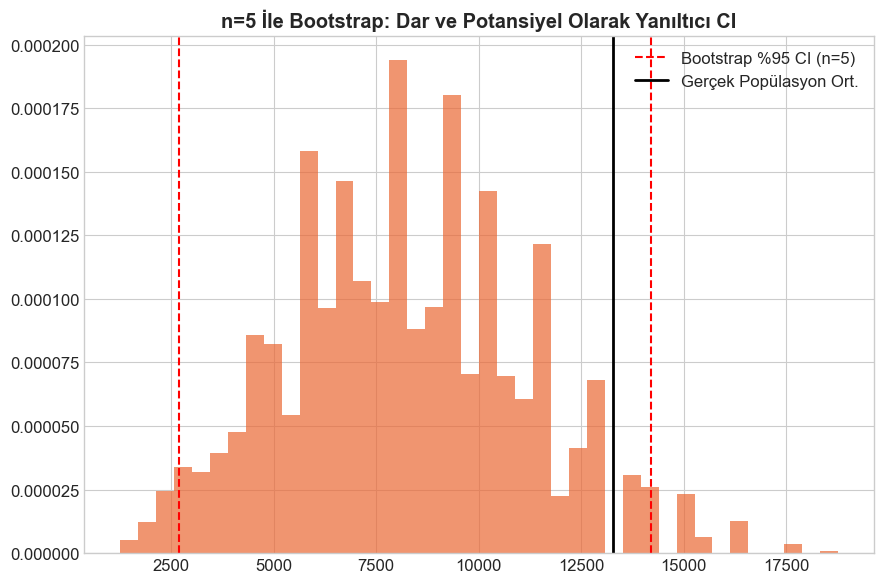


YORUM: n=5 örneklemi popülasyonu iyi temsil etmiyorsa, bootstrap bu 'kör noktayı'
miras alıyor ve CI olması gerekenden çok daha dar/yanlış yerde çıkabiliyor. Bootstrap
'sihirli' değil - hâlâ orijinal örneklemin kalitesine bağımlı. Genel kural: n < 20-30
gibi çok küçük örneklemlerde bootstrap sonuçlarına temkinli yaklaş.


In [7]:
gercek_populasyon_ortalamasi = insurance['charges'].mean()
print(f"'Gerçek' popülasyon ortalaması (tüm 1338 kişiden): {gercek_populasyon_ortalamasi:.2f}")

kucuk_ornek = rng.choice(insurance['charges'].values, size=5, replace=False)
print(f"\nÇOK küçük örneklem (n=5): {kucuk_ornek}")
print(f"Bu küçük örneklemin ortalaması: {kucuk_ornek.mean():.2f}")

bootstrap_kucuk = np.array([
    rng.choice(kucuk_ornek, size=5, replace=True).mean() for _ in range(10000)
])
ci_kucuk = np.percentile(bootstrap_kucuk, [2.5, 97.5])
print(f"Bootstrap %95 CI (n=5'ten): [{ci_kucuk[0]:.2f}, {ci_kucuk[1]:.2f}]")
print(f"Gerçek popülasyon ortalaması bu aralıkta mı? "
      f"{'EVET' if ci_kucuk[0] <= gercek_populasyon_ortalamasi <= ci_kucuk[1] else 'HAYIR - CI gerçek değeri KAÇIRDI!'}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(bootstrap_kucuk, bins=40, color='#eb6834', alpha=0.7, density=True)
ax.axvline(ci_kucuk[0], color='red', linestyle='--', label='Bootstrap %95 CI (n=5)')
ax.axvline(ci_kucuk[1], color='red', linestyle='--')
ax.axvline(gercek_populasyon_ortalamasi, color='black', linestyle='-', linewidth=2, label='Gerçek Popülasyon Ort.')
ax.set_title('n=5 İle Bootstrap: Dar ve Potansiyel Olarak Yanıltıcı CI', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: n=5 örneklemi popülasyonu iyi temsil etmiyorsa, bootstrap bu 'kör noktayı'")
print("miras alıyor ve CI olması gerekenden çok daha dar/yanlış yerde çıkabiliyor. Bootstrap")
print("'sihirli' değil - hâlâ orijinal örneklemin kalitesine bağımlı. Genel kural: n < 20-30")
print("gibi çok küçük örneklemlerde bootstrap sonuçlarına temkinli yaklaş.")

---
# 📊 R Uygulaması

Python'da işlediğimiz üç konuyu (ortalama, medyan, korelasyon için bootstrap CI) R'da
tekrarlıyoruz — `replicate()` fonksiyonu yine ana aracımız.

In [8]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 💵 R 1 — Bootstrap CI: Ortalama İçin

**Yeni R kavramı yok** — Python'daki mantığın birebir tekrarı, `replicate()` + `sample()`.

Örneklem ortalaması: 2.998279 
Bootstrap %95 CI: 2.831183 3.172383 


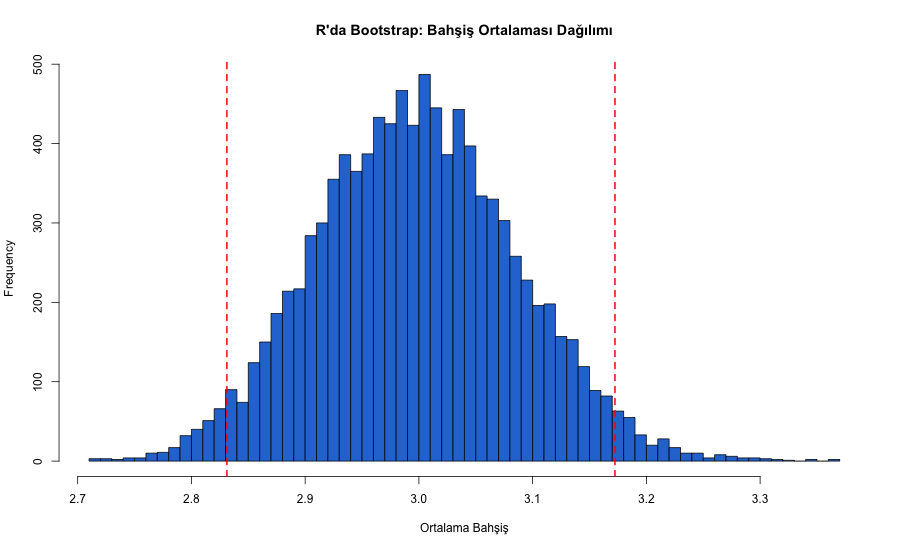

In [9]:
%%R -i tips -w 900 -h 550

set.seed(42)
bahsis_r <- tips$tip
n_r <- length(bahsis_r)
B <- 10000

bootstrap_ortalamalar_r <- replicate(B, mean(sample(bahsis_r, n_r, replace = TRUE)))
ci_bootstrap_r <- quantile(bootstrap_ortalamalar_r, c(0.025, 0.975))

cat("Örneklem ortalaması:", mean(bahsis_r), "\n")
cat("Bootstrap %95 CI:", ci_bootstrap_r, "\n")

hist(bootstrap_ortalamalar_r, breaks = 60, col = "#2a78d6",
     main = "R'da Bootstrap: Bahşiş Ortalaması Dağılımı", xlab = "Ortalama Bahşiş")
abline(v = ci_bootstrap_r, col = "red", lwd = 2, lty = 2)

---
### 📊 R 2 — Bootstrap CI: Medyan İçin

**Yeni R kavramı yok** — `median()` fonksiyonunu `mean()` yerine kullanmak yeterli, algoritma birebir aynı.

Örneklem medyanı: 2.9 
Bootstrap %95 CI (medyan): 2.5 3 


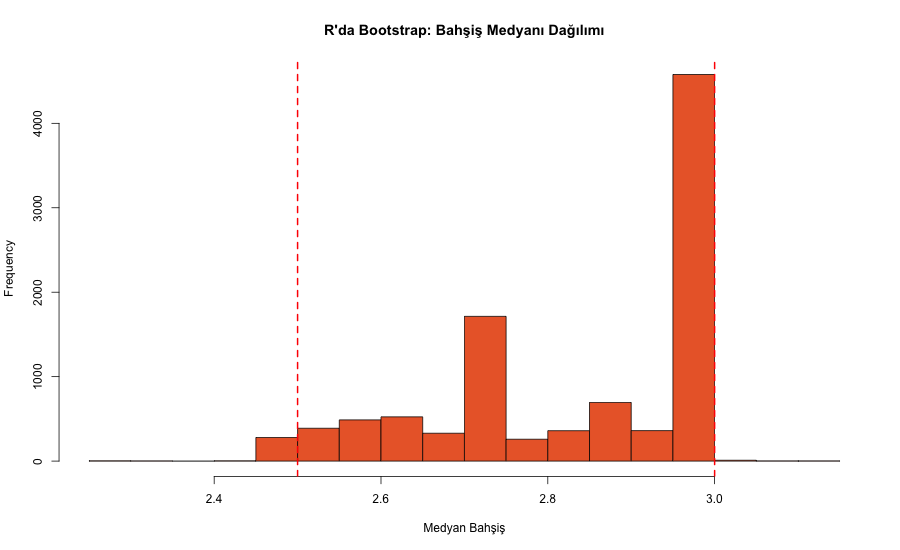

In [10]:
%%R -i tips -w 900 -h 550

medyan_gercek_r <- median(bahsis_r)
bootstrap_medyanlar_r <- replicate(B, median(sample(bahsis_r, n_r, replace = TRUE)))
ci_medyan_r <- quantile(bootstrap_medyanlar_r, c(0.025, 0.975))

cat("Örneklem medyanı:", medyan_gercek_r, "\n")
cat("Bootstrap %95 CI (medyan):", ci_medyan_r, "\n")

hist(bootstrap_medyanlar_r, breaks = 30, col = "#eb6834",
     main = "R'da Bootstrap: Bahşiş Medyanı Dağılımı", xlab = "Medyan Bahşiş")
abline(v = ci_medyan_r, col = "red", lwd = 2, lty = 2)

---
### 🔗 R 3 — Bootstrap CI: Korelasyon İçin

**Yeni R kavramı:** `sample.int(n, replace=TRUE)` ile **indeksleri** örnekleyip, hem `age`
hem `charges`'ı aynı indekslerle çekmek — Python 3'teki `paired=True` mantığının R karşılığı
(çiftlerin birbirinden kopmaması için).

Örneklem korelasyonu: 0.2990082 
Bootstrap %95 CI: 0.2489174 0.3472609 


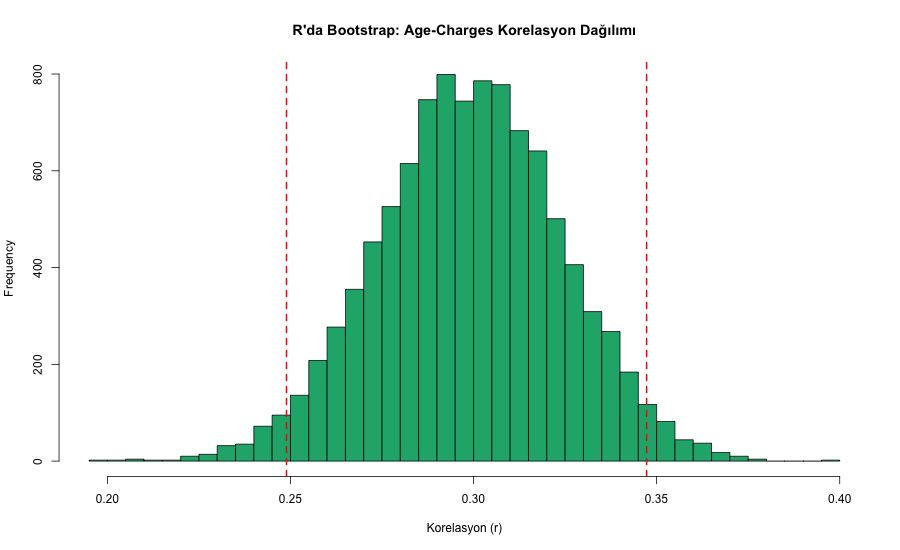

In [11]:
%%R -i insurance -w 900 -h 550

age_r <- insurance$age
charges_r <- insurance$charges
n_ins_r <- length(age_r)

r_gercek_r <- cor(age_r, charges_r)
cat("Örneklem korelasyonu:", r_gercek_r, "\n")

set.seed(42)
bootstrap_corr_r <- replicate(B, {
  idx <- sample.int(n_ins_r, n_ins_r, replace = TRUE)  # AYNI indeksler her iki degiskene de uygulanir
  cor(age_r[idx], charges_r[idx])
})
ci_corr_r <- quantile(bootstrap_corr_r, c(0.025, 0.975))
cat("Bootstrap %95 CI:", ci_corr_r, "\n")

hist(bootstrap_corr_r, breaks = 60, col = "#1baf7a",
     main = "R'da Bootstrap: Age-Charges Korelasyon Dağılımı", xlab = "Korelasyon (r)")
abline(v = ci_corr_r, col = "red", lwd = 2, lty = 2)

---
# 🗄️ SQL Uygulaması (DuckDB)

Gerçek "yerine koyarak" bootstrap'ı SQL'de verimli yapmanın kalıbı: her tekrar (`rep_id`) için,
orijinal tablonun satır sayısı kadar **rastgele satır numarası** üretip bu numaralara karşılık
gelen satırları `JOIN` ile çekmek. Bu, `RANDOM()` ile gerçek "yerine koyarak" örneklemeyi simüle ediyor.

In [12]:
import duckdb
con = duckdb.connect()
con.register('insurance_tbl', insurance)
con.register('tips_tbl', tips)
print('DuckDB hazır ✓')

DuckDB hazır ✓


---
### 💵 SQL 1 — Bootstrap CI: Ortalama İçin

**Ne yapıyoruz?**  
1000 tekrarın her birinde, `insurance_tbl`'in satır sayısı kadar rastgele satır numarası
üretip (yerine koyarak, yani tekrar edebilir) bu satırların `charges` ortalamasını hesaplıyoruz.

In [13]:
sql_bootstrap_mean = con.execute("""
    WITH pop AS (
        SELECT charges, row_number() OVER () AS rn FROM insurance_tbl
    ),
    n_count AS (SELECT COUNT(*) AS n FROM pop),
    replikalar AS (
        SELECT
            rep_id,
            CAST(1 + FLOOR(random() * (SELECT n FROM n_count)) AS INT) AS secilen_satir
        FROM range(1000) AS t1(rep_id)
        CROSS JOIN range((SELECT n FROM n_count)) AS t2(pos)
    )
    SELECT
        r.rep_id,
        AVG(p.charges) AS bootstrap_ortalama
    FROM replikalar r
    JOIN pop p ON p.rn = r.secilen_satir
    GROUP BY r.rep_id
""").df()

ci_sql_mean = sql_bootstrap_mean['bootstrap_ortalama'].quantile([0.025, 0.975])
print(f"SQL Bootstrap %95 CI (ortalama): [{ci_sql_mean.iloc[0]:.2f}, {ci_sql_mean.iloc[1]:.2f}]")
print(f"Python 1'deki CI ile karşılaştır: [{ci_bootstrap[0]:.2f}, {ci_bootstrap[1]:.2f}]")
print("(Not: tips vs insurance farklı değişkenler olduğu için sayılar birebir eşleşmeyecek,")
print("ama YÖNTEMİN aynı mantıkla çalıştığını doğrulamak için insurance.csv üzerinde tekrarladık.)")

SQL Bootstrap %95 CI (ortalama): [12594.01, 13879.60]
Python 1'deki CI ile karşılaştır: [2.83, 3.17]
(Not: tips vs insurance farklı değişkenler olduğu için sayılar birebir eşleşmeyecek,
ama YÖNTEMİN aynı mantıkla çalıştığını doğrulamak için insurance.csv üzerinde tekrarladık.)


---
### 📊 SQL 2 — Bootstrap CI: Medyan İçin

**Ne yapıyoruz?**  
Aynı kalıbı, `AVG()` yerine DuckDB'nin `MEDIAN()` fonksiyonuyla tekrarlıyoruz.

In [14]:
sql_bootstrap_median = con.execute("""
    WITH pop AS (
        SELECT charges, row_number() OVER () AS rn FROM insurance_tbl
    ),
    n_count AS (SELECT COUNT(*) AS n FROM pop),
    replikalar AS (
        SELECT
            rep_id,
            CAST(1 + FLOOR(random() * (SELECT n FROM n_count)) AS INT) AS secilen_satir
        FROM range(500) AS t1(rep_id)
        CROSS JOIN range((SELECT n FROM n_count)) AS t2(pos)
    )
    SELECT
        r.rep_id,
        MEDIAN(p.charges) AS bootstrap_medyan
    FROM replikalar r
    JOIN pop p ON p.rn = r.secilen_satir
    GROUP BY r.rep_id
""").df()

ci_sql_median = sql_bootstrap_median['bootstrap_medyan'].quantile([0.025, 0.975])
print(f"SQL Bootstrap %95 CI (medyan): [{ci_sql_median.iloc[0]:.2f}, {ci_sql_median.iloc[1]:.2f}]")
print(f"Gerçek örneklem medyanı: {insurance['charges'].median():.2f}")

SQL Bootstrap %95 CI (medyan): [8823.28, 9875.15]
Gerçek örneklem medyanı: 9382.03


---
### 🗺️ SQL 3 — Bölge Bazlı Bootstrap Karşılaştırması

**Ne yapıyoruz?**  
Her `region` için AYRI AYRI bootstrap ortalaması hesaplayıp, hangi bölgenin ortalama
harcamasının istatistiksel olarak daha "belirsiz" (geniş CI) olduğunu karşılaştırıyoruz —
küçük örneklemli bölgelerin CI'ının daha geniş olması beklenir (Bölüm 5'teki sınırlama kuralı).

In [15]:
sql_region_bootstrap = con.execute("""
    WITH pop AS (
        SELECT region, charges, row_number() OVER (PARTITION BY region) AS rn
        FROM insurance_tbl
    ),
    n_per_region AS (
        SELECT region, COUNT(*) AS n FROM pop GROUP BY region
    ),
    replikalar AS (
        SELECT
            npr.region,
            t1.rep_id,
            CAST(1 + FLOOR(random() * npr.n) AS INT) AS secilen_satir
        FROM n_per_region npr
        CROSS JOIN range(300) AS t1(rep_id)
        CROSS JOIN range(1000) AS t2(pos)  -- guvenli ust sinir, asagida gercek n ile filtrelenecek
        WHERE t2.pos < npr.n
    ),
    bootstrap_sonuc AS (
        SELECT
            r.region, r.rep_id, AVG(p.charges) AS ortalama
        FROM replikalar r
        JOIN pop p ON p.region = r.region AND p.rn = r.secilen_satir
        GROUP BY r.region, r.rep_id
    )
    SELECT
        region,
        COUNT(*) AS n_tekrar,
        ROUND(QUANTILE_CONT(ortalama, 0.025), 2) AS ci_alt,
        ROUND(QUANTILE_CONT(ortalama, 0.975), 2) AS ci_ust,
        ROUND(QUANTILE_CONT(ortalama, 0.975) - QUANTILE_CONT(ortalama, 0.025), 2) AS ci_genisligi
    FROM bootstrap_sonuc
    GROUP BY region
    ORDER BY ci_genisligi DESC
""").df()

print(sql_region_bootstrap.to_string(index=False))
print("\nYORUM: ci_genisligi sütunu, hangi bölgenin tahmininin daha 'belirsiz' olduğunu gösteriyor.")

   region  n_tekrar   ci_alt   ci_ust  ci_genisligi
southeast       300 13444.77 16215.11       2770.34
northeast       300 12156.96 14666.92       2509.96
southwest       300 11030.71 13451.79       2421.08
northwest       300 11208.42 13591.88       2383.46

YORUM: ci_genisligi sütunu, hangi bölgenin tahmininin daha 'belirsiz' olduğunu gösteriyor.


---
## ✏️ Egzersizler

### **E1 (Python) - BMI ike Bootstrap Hesabı** 
`insurance.csv`'de `bmi` (vücut kitle indeksi) için bootstrap ile %95 CI
hesapla, hem ortalama hem medyan için. Hangisinin CI'ı daha dar/geniş, neden olabilir?

In [17]:
bmi = insurance['bmi'].values
n = len(bmi)
print(f"Veri: {n} kişi, ortalama BMI: {bmi.mean():.3f}, medyan BMI: {np.median(bmi):.3f}")

rng = np.random.default_rng(42)
B = 10000
bootstrap_ortalamalar = np.array([
    rng.choice(bmi, size=len(bmi), replace=True).mean() for _ in range(B)
])
ci_bootstrap = np.percentile(bootstrap_ortalamalar, [2.5, 97.5])
print(f"Bootstrap 95% güven aralığı: [{ci_bootstrap[0]:.3f}, {ci_bootstrap[1]:.3f}]")

bootstrap_medyanlar = np.array([
    np.median(rng.choice(bmi, size=len(bmi), replace=True)) for _ in range(B)
])
ci_medyan = np.percentile(bootstrap_medyanlar, [2.5, 97.5])
print(f"Bootstrap 95% güven aralığı (medyan): [{ci_medyan[0]:.3f}, {ci_medyan[1]:.3f}]")

print("\n CI Genişliği = Üst sınır - Alt sınır")
print(f"Bootstrap 95% güven aralığı (ortalama): {ci_bootstrap[1] - ci_bootstrap[0]:.3f}")
print(f"Bootstrap 95% güven aralığı (medyan): {ci_medyan[1] - ci_medyan[0]:.3f}")

Veri: 1338 kişi, ortalama BMI: 30.663, medyan BMI: 30.400
Bootstrap 95% güven aralığı: [30.328, 30.985]
Bootstrap 95% güven aralığı (medyan): [30.020, 30.800]

 CI Genişliği = Üst sınır - Alt sınır
Bootstrap 95% güven aralığı (ortalama): 0.657
Bootstrap 95% güven aralığı (medyan): 0.780


---
### **E2 (Python + SQL) total_bill için Standart Sapma Bootstrap**
`tips` veri setinde `total_bill`'in **standart sapması** için bootstrap
CI'ı hem Python'da hem SQL'de (SQL 1'deki kalıbı `AVG` yerine `STDDEV_POP` ile) hesapla,
iki sonucu karşılaştır.

In [21]:
sql_bootstrap_total_bill = con.execute("""
    WITH pop AS (
        SELECT total_bill, row_number() OVER () AS rn FROM tips_tbl
    ),
    n_count AS (SELECT COUNT(*) AS n FROM pop),
    replikalar AS (
        SELECT
            rep_id,
            CAST(1 + FLOOR(random() * (SELECT n FROM n_count)) AS INT) AS secilen_satir
        FROM range(1000) AS t1(rep_id)
        CROSS JOIN range((SELECT n FROM n_count)) AS t2(pos)
    )
    SELECT
        r.rep_id,
        STDDEV_POP(p.total_bill) AS bootstrap_stddev
    FROM replikalar r
    JOIN pop p ON p.rn = r.secilen_satir
    GROUP BY r.rep_id
""").df()

ci_sql_stddev = sql_bootstrap_total_bill['bootstrap_stddev'].quantile([0.025, 0.975])
print(f"SQL Bootstrap %95 CI (stddev): [{ci_sql_stddev.iloc[0]:.3f}, {ci_sql_stddev.iloc[1]:.3f}]")

total_bill = tips['total_bill'].values
rng = np.random.default_rng(42)

sonuc = stats.bootstrap(
    (total_bill,), np.std, n_resamples=10000, method='percentile', random_state=42
)
print(f"Python Bootstrap %95 CI (stddev): [{sonuc.confidence_interval.low:.3f}, {sonuc.confidence_interval.high:.3f}]")

SQL Bootstrap %95 CI (stddev): [7.869, 9.829]
Python Bootstrap %95 CI (stddev): [7.878, 9.825]


---
### **E3 (Python + SQL) - Smoker Durumuna Göre Ortalama Charges Farkı Bootstrap Hesabı**
`insurance.csv`'de `smoker` durumuna göre (evet/hayır) ayrılmış iki
grubun ortalama `charges` **farkının** (`sigara_iceni_ortalama - icmeyen_ortalama`) bootstrap
güven aralığını üç dilde de hesapla. Aralık sıfırı içeriyor mu, yoksa fark istatistiksel
olarak anlamlı mı?

In [39]:
sql_smoker = con.execute("""
    WITH indexed_data AS (
        -- Grupları kendi içlerinde 1'den N'e kadar ayrı ayrı numaralandırıyoruz (Tabakalı Yapı)
        SELECT 
            charges,
            smoker,
            ROW_NUMBER() OVER(PARTITION BY smoker ORDER BY random()) AS group_rn
        FROM insurance_tbl
    ),
    group_counts AS (
        -- Her grubun orijinal eleman sayısını buluyoruz
        SELECT 
            smoker, 
            COUNT(*) AS group_n 
        FROM insurance_tbl 
        GROUP BY smoker
    ),
    replikalar AS (
        -- 10,000 replikasyon adımı tanımlıyoruz
        SELECT generate_series AS rep_id FROM generate_series(1, 10000)
    ),
    smoker_resample AS (
        -- Sigara içenleri kendi içinde iadeli örnekleme
        SELECT 
            r.rep_id,
            'yes' AS smoker,
            CAST(1 + FLOOR(random() * (SELECT group_n FROM group_counts WHERE smoker='yes')) AS INT) AS secilen_satir
        FROM replikalar r
        CROSS JOIN range((SELECT group_n FROM group_counts WHERE smoker='yes'))
    ),
    non_smoker_resample AS (
        -- Sigara içmeyenleri kendi içinde iadeli örnekleme
        SELECT 
            r.rep_id,
            'no' AS smoker,
            CAST(1 + FLOOR(random() * (SELECT group_n FROM group_counts WHERE smoker='no')) AS INT) AS secilen_satir
        FROM replikalar r
        CROSS JOIN range((SELECT group_n FROM group_counts WHERE smoker='no'))
    ),
    combined_resamples AS (
        SELECT * FROM smoker_resample UNION ALL SELECT * FROM non_smoker_resample
    ),
    bootstrap_raw AS (
        -- Rastgele seçilen satır kimliklerini gerçek ücretlerle bağlıyoruz
        SELECT 
            cr.rep_id,
            cr.smoker,
            idx.charges
        FROM combined_resamples cr
        JOIN indexed_data idx ON idx.smoker = cr.smoker AND idx.group_rn = cr.secilen_satir
    ),
    boot_diffs AS (
        -- Her replikasyon (rep_id) için ortalamaların farkını alıyoruz
        SELECT
            rep_id,
            AVG(CASE WHEN smoker = 'yes' THEN charges END) - 
            AVG(CASE WHEN smoker = 'no' THEN charges END) AS bootstrap_fark
        FROM bootstrap_raw
        GROUP BY rep_id
    ),
    ordered_diffs AS (
        -- Farkları yüzdelik dilim hesabı için sıralıyoruz
        SELECT 
            bootstrap_fark,
            ROW_NUMBER() OVER (ORDER BY bootstrap_fark) AS row_num,
            COUNT(*) OVER () AS total_rows
        FROM boot_diffs
    )
    -- %2.5 ve %97.5 yüzdelik dilim sınırlarını çekiyoruz
    SELECT 
        MIN(CASE WHEN row_num = CAST(total_rows * 0.025 AS INT) THEN bootstrap_fark END) AS ci_lower,
        MIN(CASE WHEN row_num = CAST(total_rows * 0.975 AS INT) THEN bootstrap_fark END) AS ci_upper
    FROM ordered_diffs;
""").df()

print(f"SQL Bootstrap %95 CI (Ortalama Farkı): [{sql_smoker['ci_lower'].iloc[0]:.2f}, {sql_smoker['ci_upper'].iloc[0]:.2f}]")

bootstrap_smoker = stats.bootstrap(
    (insurance['charges'][insurance['smoker'] == 'yes'].values,
     insurance['charges'][insurance['smoker'] == 'no'].values),
    lambda x, y: np.mean(x) - np.mean(y),
    n_resamples=10000, method='percentile', random_state=42, paired=False
)
print(f"Python Bootstrap %95 CI (Ortalama Farkı): [{bootstrap_smoker.confidence_interval.low:.2f}, {bootstrap_smoker.confidence_interval.high:.2f}]")


SQL Bootstrap %95 CI (Ortalama Farkı): [22189.50, 25041.93]
Python Bootstrap %95 CI (Ortalama Farkı): [22177.14, 25063.98]


### **E4 (R).** 
`tips` veri setinde `sex` (cinsiyet) gruplarına göre bahşiş oranının
(`tip/total_bill`) medyanını bootstrap ile karşılaştır — R 2'deki medyan kalıbını iki gruba
ayrı ayrı uygula, sonra iki CI'ın örtüşüp örtüşmediğini görsel olarak (`hist()` ile üst üste) göster.

Erkek: n= 157 , medyan= 0.1534919 
Kadın: n= 87 , medyan= 0.1555815 

Erkek Bootstrap %95 CI: 0.1448226 0.1605416 
Kadın Bootstrap %95 CI: 0.15 0.1747649 
İki CI örtüşüyor mu: TRUE 


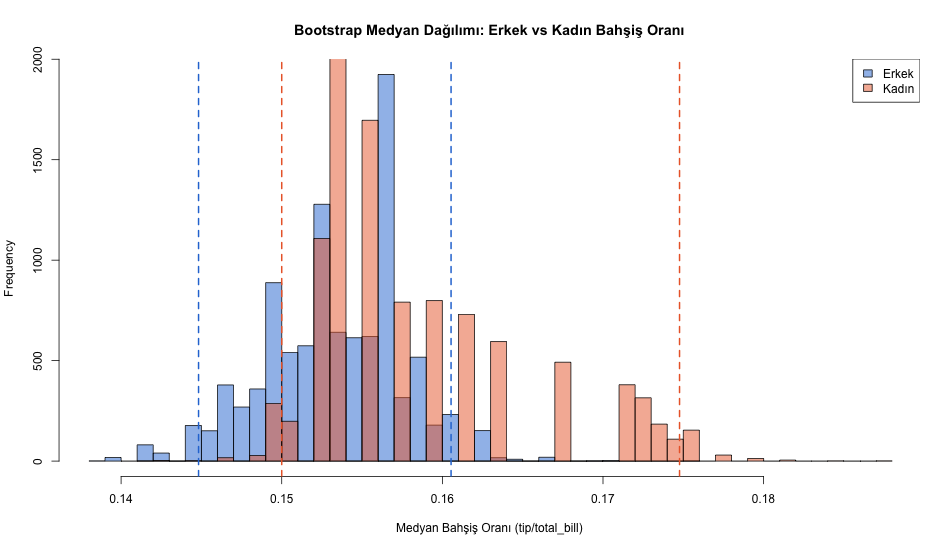

In [53]:
%%R -i tips -w 950 -h 550

tips$tip_rate <- tips$tip / tips$total_bill

erkek_r <- tips$tip_rate[tips$sex == "Male"]
kadin_r <- tips$tip_rate[tips$sex == "Female"]

cat("Erkek: n=", length(erkek_r), ", medyan=", median(erkek_r), "\n")
cat("Kadın: n=", length(kadin_r), ", medyan=", median(kadin_r), "\n\n")

set.seed(42)
B <- 10000
boot_erkek <- replicate(B, median(sample(erkek_r, length(erkek_r), replace = TRUE)))
boot_kadin <- replicate(B, median(sample(kadin_r, length(kadin_r), replace = TRUE)))

ci_erkek <- quantile(boot_erkek, c(0.025, 0.975))
ci_kadin <- quantile(boot_kadin, c(0.025, 0.975))

cat("Erkek Bootstrap %95 CI:", ci_erkek, "\n")
cat("Kadın Bootstrap %95 CI:", ci_kadin, "\n")

ortusuyor_mu <- !(ci_erkek[2] < ci_kadin[1] || ci_kadin[2] < ci_erkek[1])
cat("İki CI örtüşüyor mu:", ortusuyor_mu, "\n")

# Ust uste histogram (once erkek, sonra yari saydam kadin)
hist(boot_erkek, breaks = 50, col = rgb(0.16, 0.47, 0.84, 0.5),
     main = "Bootstrap Medyan Dağılımı: Erkek vs Kadın Bahşiş Oranı",
     xlab = "Medyan Bahşiş Oranı (tip/total_bill)",
     xlim = range(c(boot_erkek, boot_kadin)))
hist(boot_kadin, breaks = 50, col = rgb(0.92, 0.41, 0.20, 0.5), add = TRUE)
abline(v = ci_erkek, col = "#2a78d6", lwd = 2, lty = 2)
abline(v = ci_kadin, col = "#eb6834", lwd = 2, lty = 2)
legend("topright", legend = c("Erkek", "Kadın"),
       fill = c(rgb(0.16, 0.47, 0.84, 0.5), rgb(0.92, 0.41, 0.20, 0.5)))


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 8.7 | Bootstrap yöntemi |
| [Efron & Tibshirani — An Introduction to the Bootstrap](https://www.taylorfrancis.com/books/mono/10.1201/9780429246593/introduction-bootstrap-bradley-efron-robert-tibshirani) | — | Bootstrap'ın orijinal/klasik referans kitabı |
| [Seeing Theory](https://seeing-theory.brown.edu/frequentist-inference) | Frequentist Inference | İnteraktif |
| [StatQuest — Bootstrapping](https://www.youtube.com/watch?v=Xz0x-8-cgaQ) | Video | Görsel anlatım |
| [scipy.stats.bootstrap Dokümantasyonu](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html) | Kütüphane | Python 3'te kullandığımız fonksiyon |
| [Kaggle — Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance) | Veri | insurance.csv kaynağı |